# Task 4: Loan Default Risk with Business Cost Optimization

## Problem Statement

Financial institutions need to identify customers who are likely to default on their loans. Accurate prediction helps reduce financial losses and supports better lending decisions.

## Objective

The objective of this project is to build classification models to predict loan default risk and optimize the decision threshold based on business costs.

## Import Required Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

plt.style.use("ggplot")

## Load Dataset

In [4]:
df = pd.read_csv("application_train.csv")

df.shape

(3864, 122)

In [5]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

## Explore Dataset

In [6]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3864 entries, 0 to 3863
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(85), int64(21), object(16)
memory usage: 3.6+ MB


In [8]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,3864.000000,3864.000000,3864.000000,3.864000e+03,3.864000e+03,3864.000000,3.863000e+03,3864.000000,3864.000000,3864.000000,...,3863.000000,3863.000000,3863.000000,3863.000000,3330.000000,3330.000000,3330.000000,3330.000000,3330.000000,3330.000000
mean,102256.062888,0.078416,0.402950,1.685222e+05,6.017847e+05,27239.107919,5.422567e+05,0.021044,-16048.218427,65288.354555,...,0.006472,0.000518,0.000518,0.000518,0.009610,0.008408,0.035736,0.266967,0.273874,1.876276
std,1304.554619,0.268860,0.713685,9.938526e+04,4.033991e+05,14522.447899,3.712203e+05,0.014162,4340.195881,142472.444044,...,0.080196,0.022751,0.022751,0.022751,0.100603,0.119783,0.195125,0.937145,0.622553,1.845735
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,2596.500000,4.500000e+04,0.000938,-25160.000000,-15632.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,101115.750000,0.000000,0.000000,1.125000e+05,2.700000e+05,16713.000000,2.385000e+05,0.010006,-19620.750000,-2707.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,102264.500000,0.000000,0.000000,1.440000e+05,5.095012e+05,25195.500000,4.500000e+05,0.018850,-15861.000000,-1201.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,103379.250000,0.000000,1.000000,2.025000e+05,8.086500e+05,34845.750000,6.795000e+05,0.028663,-12418.000000,-281.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,104519.000000,1.000000,7.000000,1.935000e+06,2.517300e+06,135936.000000,2.254500e+06,0.072508,-7705.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,2.000000,4.000000,3.000000,16.000000,8.000000,11.000000


In [9]:
df['TARGET'].value_counts()

,count
TARGET,
0,3561
1,303


In [10]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
COMMONAREA_AVG,2675
COMMONAREA_MODE,2675
COMMONAREA_MEDI,2675
NONLIVINGAPARTMENTS_MEDI,2660
NONLIVINGAPARTMENTS_MODE,2660
NONLIVINGAPARTMENTS_AVG,2660
LIVINGAPARTMENTS_AVG,2623
LIVINGAPARTMENTS_MODE,2623
LIVINGAPARTMENTS_MEDI,2623
FONDKAPREMONT_MODE,2603


## Data Cleaning

In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False).head(20)

,0
COMMONAREA_AVG,69.228778
COMMONAREA_MODE,69.228778
COMMONAREA_MEDI,69.228778
NONLIVINGAPARTMENTS_MEDI,68.840580
NONLIVINGAPARTMENTS_MODE,68.840580
NONLIVINGAPARTMENTS_AVG,68.840580
LIVINGAPARTMENTS_AVG,67.883023
LIVINGAPARTMENTS_MODE,67.883023
LIVINGAPARTMENTS_MEDI,67.883023
FONDKAPREMONT_MODE,67.365424


In [12]:
columns_to_drop = missing_percent[missing_percent > 50].index

df = df.drop(columns=columns_to_drop)

print(df.shape)

(3864, 88)


In [13]:
categorical_cols = df.select_dtypes(include='object').columns

numerical_cols = df.select_dtypes(exclude='object').columns

print("Categorical Columns:", len(categorical_cols))

print("Numerical Columns:", len(numerical_cols))

Categorical Columns: 14
Numerical Columns: 74


In [14]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [15]:
df.isnull().sum().sum()

np.int64(0)

## Label Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [17]:
X = df.drop('TARGET', axis=1)

y = df['TARGET']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(3091, 87)
(773, 87)


## Logistic Regression Model

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9340232858990944


## CatBoost Model

In [22]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [23]:
from catboost import CatBoostClassifier

In [24]:
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, random_seed=42, verbose=0)

In [25]:
cat_pred = cat_model.predict(X_test)

In [26]:
cat_accuracy = accuracy_score(y_test, cat_pred)

print("CatBoost Accuracy:", cat_accuracy)

CatBoost Accuracy: 0.9327296248382924


## Feature Importance

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cat_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
40,EXT_SOURCE_3,10.819401
39,EXT_SOURCE_2,8.477049
19,DAYS_ID_PUBLISH,4.471874
17,DAYS_EMPLOYED,4.294396
31,HOUR_APPR_PROCESS_START,3.989433
16,DAYS_BIRTH,3.901301
0,SK_ID_CURR,3.719470
7,AMT_CREDIT,3.489431
60,DAYS_LAST_PHONE_CHANGE,3.442535
12,NAME_EDUCATION_TYPE,3.336640


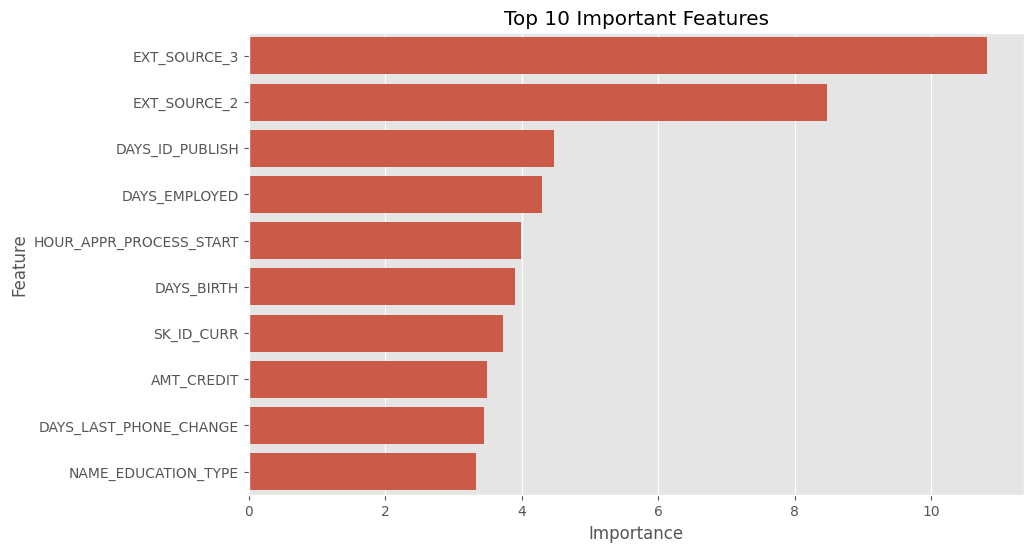

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

## Business Cost Optimization

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, cat_pred)

cm

array([[721,   1],
       [ 51,   0]])

In [30]:
TN, FP, FN, TP = cm.ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

TN: 721
FP: 1
FN: 51
TP: 0


In [31]:
false_positive_cost = 1000

false_negative_cost = 5000

total_cost = (FP * false_positive_cost) + (FN * false_negative_cost)

print("Total Business Cost: $", total_cost)

Total Business Cost: $ 256000


## Threshold Optimization

In [32]:
probabilities = cat_model.predict_proba(X_test)[:,1]

In [33]:
threshold = 0.30

optimized_prediction = (probabilities >= threshold).astype(int)

In [34]:
optimized_accuracy = accuracy_score(
    y_test,
    optimized_prediction
)

print("Optimized Accuracy:", optimized_accuracy)

Optimized Accuracy: 0.9236739974126779


In [35]:
optimized_cm = confusion_matrix(
    y_test,
    optimized_prediction
)

optimized_cm

array([[711,  11],
       [ 48,   3]])

# Conclusion

In this project, loan default prediction was performed using Logistic Regression and CatBoost models. After preprocessing and handling missing values, both models were trained and evaluated.

CatBoost provided strong predictive performance and feature importance analysis identified the most influential variables affecting loan default.

Business cost optimization was performed by assigning different costs to false positives and false negatives. The prediction threshold was adjusted to improve business decision-making and reduce financial risk.

Overall, this project demonstrated a complete machine learning workflow for credit risk assessment, combining predictive modeling with business-oriented evaluation.